Drive Mount

In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Zip the File

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Physionet.zip"

extract_path = "/content/physionet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
print(os.listdir(extract_path))

['classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0']


In [ ]:
!pip install librosa pywavelets scikit-learn pandas matplotlib

IMPORT LIBARIES

In [ ]:
import os
import librosa
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Preprocessing

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import pywt

folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

base_path = "/content/physionet/physionet.0.0"

X = []
y = []

for folder in folders:

    folder_path = os.path.join(
        base_path,
        folder
    )

    reference_path = os.path.join(
        folder_path,
        "REFERENCE.csv"
    )

    labels = pd.read_csv(
        reference_path,
        header=None
    )

    labels.columns = [
        "file",
        "label"
    ]

    # Label mapping
    labels["label"] = labels[
        "label"
    ].map({
        -1: 0,
         1: 1
    })

    print(f"Processing {folder}")

    for _, row in labels.iterrows():

        file_id = row["file"]
        label = row["label"]

        wav_path = os.path.join(
            folder_path,
            file_id + ".wav"
        )

        try:

            # Load audio
            signal, sr = librosa.load(
                wav_path,
                sr=22050
            )

            # Normalize
            signal = librosa.util.normalize(
                signal
            )

            # ======================
            # DWT DENOISING
            # ======================
            coeffs = pywt.wavedec(
                signal,
                'db4',
                level=4
            )

            coeffs[1:] = [
                pywt.threshold(
                    c,
                    0.04,
                    mode='soft'
                )
                for c in coeffs[1:]
            ]

            denoised = pywt.waverec(
                coeffs,
                'db4'
            )

            # ======================
            # MFCC FEATURES
            # ======================
            mfcc = librosa.feature.mfcc(
                y=denoised,
                sr=sr,
                n_mfcc=100
            )

            # Better feature extraction
            mfcc_mean = np.mean(
                mfcc,
                axis=1
            )

            mfcc_std = np.std(
                mfcc,
                axis=1
            )

            mfcc_max = np.max(
                mfcc,
                axis=1
            )

            # Final feature vector
            feature_vector = np.hstack([
                mfcc_mean,
                mfcc_std,
                mfcc_max
            ])

            X.append(
                feature_vector
            )

            y.append(
                label
            )

        except Exception as e:

            print(
                "Error:",
                wav_path,
                e
            )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Processing training-a
Processing training-b
Processing training-c
Processing training-d
Processing training-e
Processing training-f
X shape: (3240, 300)
y shape: (3240,)


DWT

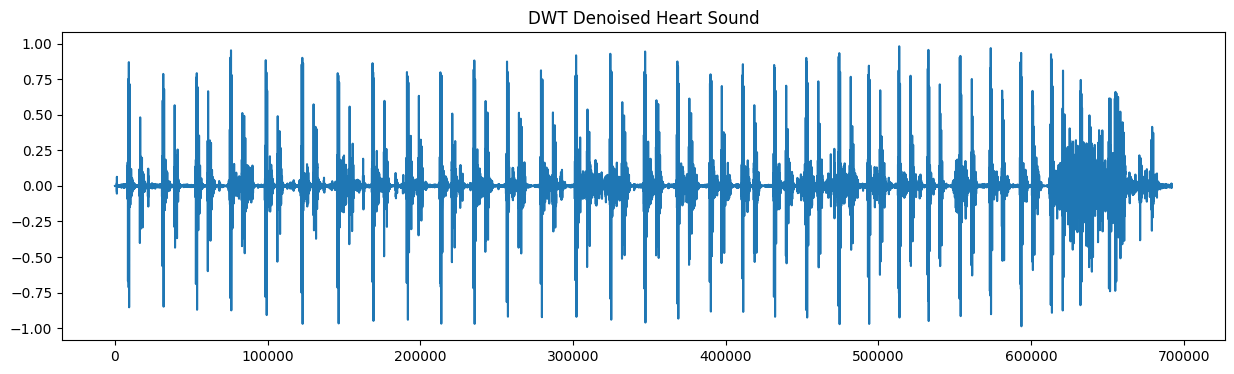

In [ ]:
import pywt
import matplotlib.pyplot as plt

coeffs = pywt.wavedec(signal, 'db4', level=4)

threshold = 0.04

coeffs[1:] = [
    pywt.threshold(c, threshold, mode='soft')
    for c in coeffs[1:]
]

denoised = pywt.waverec(coeffs, 'db4')

plt.figure(figsize=(15,4))
plt.plot(denoised)
plt.title("DWT Denoised Heart Sound")
plt.show()

In [ ]:
print(np.bincount(y))

[]


MFCC

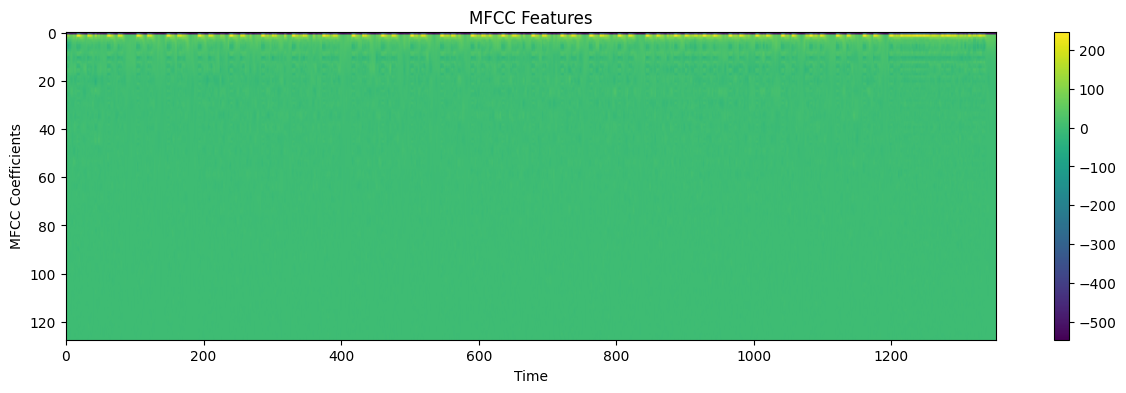

(128, 1352)


In [ ]:
mfcc = librosa.feature.mfcc(
    y=denoised,
    sr=sr,
    n_mfcc=150
)

plt.figure(figsize=(15,4))
plt.imshow(mfcc, aspect='auto')
plt.colorbar()
plt.title("MFCC Features")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.show()

print(mfcc.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Balance dataset
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_scaled,
    y
)

print(np.bincount(y_resampled))

[2575 2575]


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2592, 300)
(648, 300)


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

joblib.dump(
    scaler,
    "/content/scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


Train SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced'
)

svm.fit(
    X_train_scaled,
    y_train
)

print("Training Completed")

Training Completed


Evaluate Model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred = svm.predict(
    X_test_scaled
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.8935185185185185
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       515
           1       0.68      0.90      0.78       133

    accuracy                           0.89       648
   macro avg       0.83      0.90      0.85       648
weighted avg       0.91      0.89      0.90       648



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred
))

Random Forest Accuracy:
0.9197530864197531

Confusion Matrix:
[[500  15]
 [ 37  96]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       515
           1       0.86      0.72      0.79       133

    accuracy                           0.92       648
   macro avg       0.90      0.85      0.87       648
weighted avg       0.92      0.92      0.92       648



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Logistic Regression
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

print("Logistic Regression Accuracy:")
print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy:
0.8719135802469136

Confusion Matrix:
[[480  35]
 [ 48  85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       515
           1       0.71      0.64      0.67       133

    accuracy                           0.87       648
   macro avg       0.81      0.79      0.80       648
weighted avg       0.87      0.87      0.87       648



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# KNN Model
knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train
knn.fit(
    X_train_scaled,
    y_train
)

# Prediction
knn_pred = knn.predict(
    X_test_scaled
)

# Accuracy
print("KNN Accuracy:")
print(
    accuracy_score(
        y_test,
        knn_pred
    )
)

# Confusion Matrix
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        knn_pred
    )
)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        knn_pred
    )
)

KNN Accuracy:
0.9135802469135802

Confusion Matrix:
[[488  27]
 [ 29 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       515
           1       0.79      0.78      0.79       133

    accuracy                           0.91       648
   macro avg       0.87      0.86      0.87       648
weighted avg       0.91      0.91      0.91       648



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    gb_pred
))

Gradient Boosting Accuracy:
0.9212962962962963

Confusion Matrix:
[[499  16]
 [ 35  98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       515
           1       0.86      0.74      0.79       133

    accuracy                           0.92       648
   macro avg       0.90      0.85      0.87       648
weighted avg       0.92      0.92      0.92       648



In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier()

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

print("AdaBoost Accuracy:")
print(accuracy_score(y_test, ada_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ada_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    ada_pred
))

AdaBoost Accuracy:
0.875

Confusion Matrix:
[[468  47]
 [ 34  99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       515
           1       0.68      0.74      0.71       133

    accuracy                           0.88       648
   macro avg       0.81      0.83      0.82       648
weighted avg       0.88      0.88      0.88       648



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred
))

Decision Tree Accuracy:
0.8503086419753086

Confusion Matrix:
[[470  45]
 [ 52  81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       515
           1       0.64      0.61      0.63       133

    accuracy                           0.85       648
   macro avg       0.77      0.76      0.77       648
weighted avg       0.85      0.85      0.85       648



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced'
)

# Train
svm.fit(
    X_train_scaled,
    y_train
)

# Prediction
pred = svm.predict(X_test_scaled)

# Accuracy
print("Accuracy:")
print(accuracy_score(y_test, pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    pred
))

# Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    pred
))

Accuracy:
0.8935185185185185

Confusion Matrix:
[[459  56]
 [ 13 120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       515
           1       0.68      0.90      0.78       133

    accuracy                           0.89       648
   macro avg       0.83      0.90      0.85       648
weighted avg       0.91      0.89      0.90       648



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.9351851851851852
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       515
           1       0.89      0.78      0.83       133

    accuracy                           0.94       648
   macro avg       0.92      0.88      0.90       648
weighted avg       0.93      0.94      0.93       648



In [ ]:
results = {

    "SVM": svm.score(
        X_test_scaled,
        y_test
    ),

    "Random Forest": rf.score(
        X_test,
        y_test
    ),

    "Decision Tree": dt.score(
        X_test,
        y_test
    ),

    "Logistic Regression": lr.score(
        X_test_scaled,
        y_test
    ),

    "KNN": knn.score(
        X_test_scaled,
        y_test
    ),

    "Gradient Boosting": gb.score(
        X_test,
        y_test
    ),

    "AdaBoost": ada.score(
        X_test,
        y_test
    ),

    "XGBoost": xgb.score(
        X_test,
        y_test
    )
}

import pandas as pd

result_df = pd.DataFrame(
    results.items(),
    columns=[
        "Model",
        "Accuracy"
    ]
)

result_df = result_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(result_df)

                 Model  Accuracy
7              XGBoost  0.935185
5    Gradient Boosting  0.921296
1        Random Forest  0.919753
4                  KNN  0.913580
0                  SVM  0.893519
6             AdaBoost  0.875000
3  Logistic Regression  0.871914
2        Decision Tree  0.850309


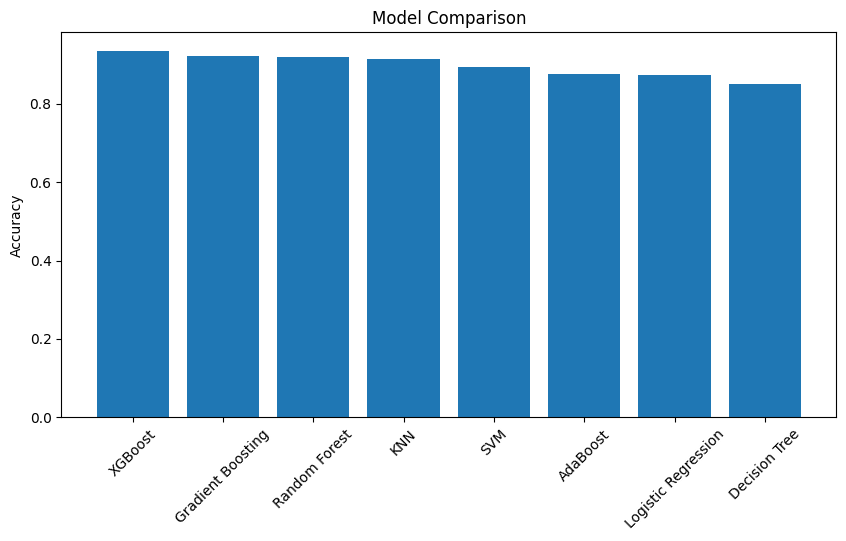

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    result_df["Model"],
    result_df["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title(
    "Model Comparison"
)

plt.show()

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report

extra = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42
)

extra.fit(X_train, y_train)

pred = extra.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.9228395061728395
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       515
           1       0.87      0.73      0.80       133

    accuracy                           0.92       648
   macro avg       0.90      0.85      0.87       648
weighted avg       0.92      0.92      0.92       648



ANN Classifier

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# ==========================
# Scaling
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# One-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# ==========================
# ANN Model
# ==========================

model = Sequential([

    Dense(
        256,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),
    Dropout(0.3),

    Dense(
        128,
        activation='relu'
    ),

    BatchNormalization(),
    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.2),

    Dense(
        2,
        activation='softmax'
    )
])

# ==========================
# Compile
# ==========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================
# Train
# ==========================

history = model.fit(

    X_train,
    y_train_cat,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    verbose=1
)

# ==========================
# Prediction
# ==========================

pred_prob = model.predict(X_test)

pred = pred_prob.argmax(axis=1)

# ==========================
# Evaluation
# ==========================

loss, accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    pred
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    pred
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.6671 - loss: 0.8048 - val_accuracy: 0.8439 - val_loss: 0.3760
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8755 - loss: 0.2963 - val_accuracy: 0.8844 - val_loss: 0.3255
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8760 - loss: 0.2749 - val_accuracy: 0.8960 - val_loss: 0.2576
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8915 - loss: 0.2490 - val_accuracy: 0.8844 - val_loss: 0.2856
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9098 - loss: 0.2173 - val_accuracy: 0.8960 - val_loss: 0.2365
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9098 - loss: 0.2114 - val_accuracy: 0.8940 - val_loss: 0.2552
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9103 - loss: 0.2031 - val_accuracy: 0.8921 - val_loss: 0.2248
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.1733 - val_accuracy: 0.8960 

Save Model

In [ ]:
joblib.dump(
    svm,
    "/content/heart_sound_model.pkl"
)

print("Model Saved")

Model Saved


Prediction

In [ ]:
import os
import librosa
import pywt
import numpy as np
import pandas as pd
import joblib

model = joblib.load(
    "/content/heart_sound_model.pkl"
)

scaler = joblib.load(
    "/content/scaler.pkl"
)

validation_path = "/content/physionet/physionet.0.0/validation"

results = []

for file_name in os.listdir(validation_path):

    if file_name.endswith(".wav"):

        file_path = os.path.join(
            validation_path,
            file_name
        )

        try:

            signal, sr = librosa.load(
                file_path,
                sr=22050
            )

            signal = librosa.util.normalize(
                signal
            )

            # DWT
            coeffs = pywt.wavedec(
                signal,
                'db4',
                level=4
            )

            coeffs[1:] = [
                pywt.threshold(
                    c,
                    0.04,
                    mode='soft'
                )
                for c in coeffs[1:]
            ]

            denoised = pywt.waverec(
                coeffs,
                'db4'
            )

            # MFCC
            mfcc = librosa.feature.mfcc(
                y=denoised,
                sr=sr,
                n_mfcc=40
            )

            feature = np.mean(
                mfcc.T,
                axis=0
            )

            feature = feature.reshape(
                1, -1
            )

            feature_scaled = scaler.transform(
                feature
            )

            pred = model.predict(
                feature_scaled
            )[0]

            score = model.decision_function(
                feature_scaled
            )[0]

            label = (
                "Normal"
                if pred == 0
                else "Abnormal"
            )

            print(
                f"{file_name} ---> "
                f"{label} "
                f"| score={score:.2f}"
            )

            results.append(
                [file_name, label]
            )

        except Exception as e:
            print(
                "Error:",
                file_name,
                e
            )

df = pd.DataFrame(
    results,
    columns=[
        "File Name",
        "Prediction"
    ]
)

df.to_csv(
    "/content/prediction_results.csv",
    index=False
)

print("\nPrediction Completed!")
print(df.head())

a0127.wav ---> Abnormal | score=0.48
e00006.wav ---> Normal | score=-2.25
a0080.wav ---> Abnormal | score=0.81
b0014.wav ---> Abnormal | score=0.39
e00022.wav ---> Normal | score=-2.47
b0106.wav ---> Abnormal | score=1.00
e00015.wav ---> Normal | score=-2.26
e00627.wav ---> Abnormal | score=1.46
e00328.wav ---> Abnormal | score=1.56
b0047.wav ---> Abnormal | score=0.73
b0242.wav ---> Abnormal | score=0.37
b0239.wav ---> Abnormal | score=0.40
a0025.wav ---> Abnormal | score=1.19
e00016.wav ---> Normal | score=-1.38
b0021.wav ---> Abnormal | score=0.88
a0106.wav ---> Abnormal | score=1.23
e00001.wav ---> Normal | score=-1.80
b0052.wav ---> Abnormal | score=0.39
b0032.wav ---> Normal | score=-0.10
a0068.wav ---> Abnormal | score=1.31
b0016.wav ---> Abnormal | score=0.04
a0040.wav ---> Abnormal | score=0.63
e00601.wav ---> Abnormal | score=1.41
b0017.wav ---> Abnormal | score=0.15
b0037.wav ---> Abnormal | score=0.91
e00176.wav ---> Abnormal | score=1.35
a0010.wav ---> Abnormal | score=1.0

Install Catboost

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


preprocessing in 150 coefficient

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import pywt

folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

base_path = "/content/physionet/physionet.0.0"

X = []
y = []

for folder in folders:

    folder_path = os.path.join(
        base_path,
        folder
    )

    reference_path = os.path.join(
        folder_path,
        "REFERENCE.csv"
    )

    labels = pd.read_csv(
        reference_path,
        header=None
    )

    labels.columns = [
        "file",
        "label"
    ]

    # Label mapping
    labels["label"] = labels[
        "label"
    ].map({
        -1: 0,
         1: 1
    })

    print(f"Processing {folder}")

    for _, row in labels.iterrows():

        file_id = row["file"]
        label = row["label"]

        wav_path = os.path.join(
            folder_path,
            file_id + ".wav"
        )

        try:

            # Load audio
            signal, sr = librosa.load(
                wav_path,
                sr=22050
            )

            # Normalize
            signal = librosa.util.normalize(
                signal
            )

            # ======================
            # DWT DENOISING
            # ======================
            coeffs = pywt.wavedec(
                signal,
                'db4',
                level=4
            )

            coeffs[1:] = [
                pywt.threshold(
                    c,
                    0.04,
                    mode='soft'
                )
                for c in coeffs[1:]
            ]

            denoised = pywt.waverec(
                coeffs,
                'db4'
            )

            # ======================
            # MFCC FEATURES
            # ======================
            mfcc = librosa.feature.mfcc(
                y=denoised,
                sr=sr,
                n_mfcc=150
            )

            # Better feature extraction
            mfcc_mean = np.mean(
                mfcc,
                axis=1
            )

            mfcc_std = np.std(
                mfcc,
                axis=1
            )

            mfcc_max = np.max(
                mfcc,
                axis=1
            )

            # Final feature vector
            feature_vector = np.hstack([
                mfcc_mean,
                mfcc_std,
                mfcc_max
            ])

            X.append(
                feature_vector
            )

            y.append(
                label
            )

        except Exception as e:

            print(
                "Error:",
                wav_path,
                e
            )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Processing training-a
Processing training-b
Processing training-c
Processing training-d
Processing training-e
Processing training-f
X shape: (3240, 384)
y shape: (3240,)


Train Different Models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {

    "SVM":
    SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced'
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(),

    "LightGBM":
    LGBMClassifier(),

    "CatBoost":
    CatBoostClassifier(
        verbose=0
    ),

    "KNN":
    KNeighborsClassifier(),

    "Logistic Regression":
    LogisticRegression(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Gradient Boosting":
    GradientBoostingClassifier(),

    "AdaBoost":
    AdaBoostClassifier(),

    "Extra Trees":
    ExtraTreesClassifier(),

    "Naive Bayes":
    GaussianNB()
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}")

    model.fit(
        X_train_scaled,
        y_train
    )

    pred = model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    print("Accuracy:", acc)

    results.append(
        [name, acc]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

print(results_df)


Training SVM
Accuracy: 0.8935185185185185

Training Random Forest
Accuracy: 0.9228395061728395

Training XGBoost
Accuracy: 0.9274691358024691

Training LightGBM
[LightGBM] [Info] Number of positive: 532, number of negative: 2060
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 2592, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205247 -> initscore=-1.353818
[LightGBM] [Info] Start training from score -1.353818


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9274691358024691

Training CatBoost
Accuracy: 0.9274691358024691

Training KNN
Accuracy: 0.9135802469135802

Training Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8734567901234568

Training Decision Tree
Accuracy: 0.875

Training Gradient Boosting
Accuracy: 0.9212962962962963

Training AdaBoost
Accuracy: 0.875

Training Extra Trees
Accuracy: 0.9243827160493827

Training Naive Bayes
Accuracy: 0.8148148148148148
                  Model  Accuracy
0                   SVM  0.893519
1         Random Forest  0.922840
2               XGBoost  0.927469
3              LightGBM  0.927469
4              CatBoost  0.927469
5                   KNN  0.913580
6   Logistic Regression  0.873457
7         Decision Tree  0.875000
8     Gradient Boosting  0.921296
9              AdaBoost  0.875000
10          Extra Trees  0.924383
11          Naive Bayes  0.814815


ML Comparision

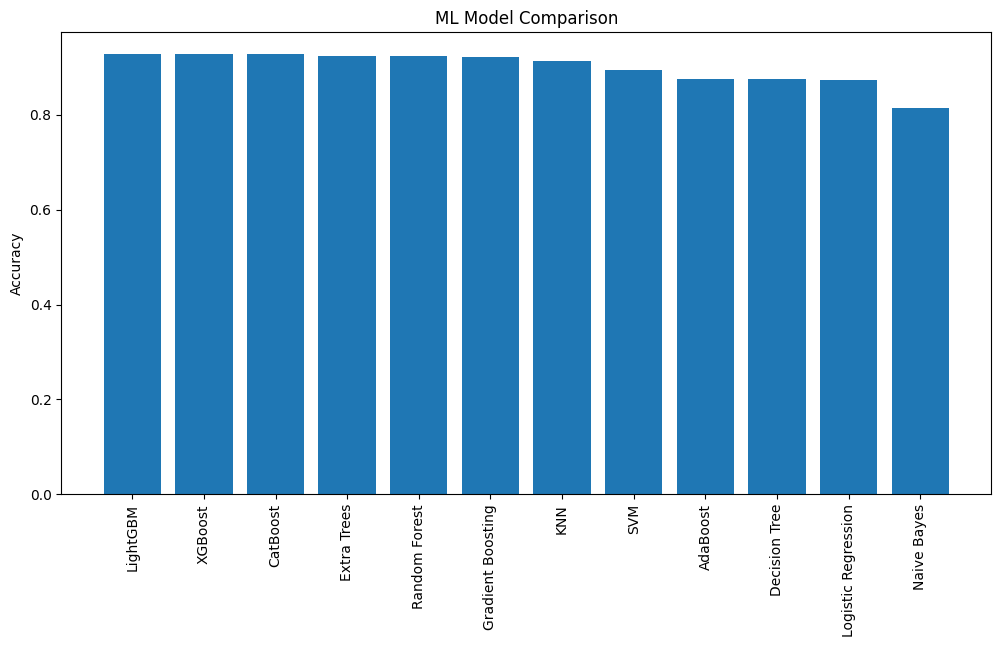

In [ ]:
import matplotlib.pyplot as plt

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=90)

plt.ylabel("Accuracy")

plt.title(
    "ML Model Comparison"
)

plt.show()

Compare different models

Install Tensorflow

In [ ]:
!pip install tensorflow

ANN Classifier

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(300,)
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

loss, acc = ann.evaluate(
    X_test_scaled,
    y_test
)

print("ANN Accuracy:", acc)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.8553 - loss: 0.3038 - val_accuracy: 0.8844 - val_loss: 0.2798
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9103 - loss: 0.2047 - val_accuracy: 0.8844 - val_loss: 0.2550
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9243 - loss: 0.1766 - val_accuracy: 0.8979 - val_loss: 0.2443
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9310 - loss: 0.1572 - val_accuracy: 0.9056 - val_loss: 0.2348
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9426 - loss: 0.1454 - val_accuracy: 0.9017 - val_loss: 0.2594
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9479 - loss: 0.1304 - val_accuracy: 0.8863 - val_loss: 0.2375
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9600 - loss: 0.1060 - val_accuracy: 0.8979 - val_loss: 0.2428
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9653 - loss: 0.1017 - val_accuracy: 0.8960 - val_loss: 0.

CNN CLASSIFIER

In [ ]:
X_cnn = []

for feature in X:

    X_cnn.append(
        feature.reshape(384,1)
    )

X_cnn = np.array(X_cnn)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Train CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense
)

cnn = Sequential([

    Conv1D(
        64,
        3,
        activation='relu',
        input_shape=(384,1)
    ),

    MaxPooling1D(2),

    Flatten(),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=100
)

loss, acc = cnn.evaluate(
    X_test_cnn,
    y_test_cnn
)

print("CNN Accuracy:", acc)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7454 - loss: 1.6280
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8576 - loss: 0.3275
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8708 - loss: 0.2887
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.2824
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8769 - loss: 0.2879
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8889 - loss: 0.2544
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8773 - loss: 0.2819
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8843 - loss: 0.2618
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8704 - loss: 0.3080
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8912 - loss: 0.2600
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8962 - loss: 0.2480
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9078 - lo

Extract MFCC for Deep Learning

In [ ]:
import os
import librosa
import pywt
import numpy as np
import pandas as pd

folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

base_path = "/content/physionet/physionet.0.0"

X = []
y = []

MAX_LEN = 200

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    label_file = os.path.join(
        folder_path,
        "REFERENCE.csv"
    )

    labels = pd.read_csv(
        label_file,
        header=None
    )

    labels.columns = ['file', 'label']

    labels['label'] = labels['label'].map({
        -1:0,
         1:1
    })

    print("Processing", folder)

    for _, row in labels.iterrows():

        file_name = row['file']
        label = row['label']

        wav_path = os.path.join(
            folder_path,
            file_name + ".wav"
        )

        try:

            signal, sr = librosa.load(
                wav_path,
                sr=None
            )

            # DWT denoise
            coeffs = pywt.wavedec(
                signal,
                'db4',
                level=4
            )

            coeffs[1:] = [
                pywt.threshold(
                    c,
                    0.04,
                    mode='soft'
                )
                for c in coeffs[1:]
            ]

            denoised = pywt.waverec(
                coeffs,
                'db4'
            )

            # MFCC
            mfcc = librosa.feature.mfcc(
                y=denoised,
                sr=sr,
                n_mfcc=80
            )

            # Padding
            if mfcc.shape[1] < MAX_LEN:

                pad_width = (
                    MAX_LEN - mfcc.shape[1]
                )

                mfcc = np.pad(
                    mfcc,
                    pad_width=((0,0),
                    (0,pad_width)),
                    mode='constant'
                )

            else:
                mfcc = mfcc[:, :MAX_LEN]

            X.append(mfcc)
            y.append(label)

        except Exception as e:
            print(e)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

Processing training-a
Processing training-b
Processing training-c
Processing training-d
Processing training-e
Processing training-f
(3240, 80, 200)
(3240,)


Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2592, 80, 200)
(648, 80, 200)


CNN Classifier

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report
)

# ==========================
# Reshape
# ==========================

X = X[..., np.newaxis]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# CNN
# ==========================

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(80,200,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=40,

    batch_size=32,

    callbacks=[early_stop]
)

# Prediction
pred = (
    model.predict(X_test) > 0.5
).astype(int)

print(classification_report(
    y_test,
    pred
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.7935 - loss: 1.4481 - val_accuracy: 0.8112 - val_loss: 0.5221
Epoch 2/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8374 - loss: 0.3472 - val_accuracy: 0.8015 - val_loss: 0.4108
Epoch 3/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8427 - loss: 0.3179 - val_accuracy: 0.8420 - val_loss: 0.3564
Epoch 4/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8548 - loss: 0.3013 - val_accuracy: 0.8593 - val_loss: 0.3257
Epoch 5/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8644 - loss: 0.2551 - val_accuracy: 0.8651 - val_loss: 0.3096
Epoch 6/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8707 - loss: 0.2361 - val_accuracy: 0.8825 - val_loss: 0.2690
Epoch 7/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8702 - loss: 0.2286 - val_accuracy: 0.8748 - val_loss: 0.2762
Epoch 8/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8997 - loss: 0.1934 - val_accuracy: 0.8728 -

CNN MODEL

LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

tf.keras.backend.clear_session()

model = Sequential()

model.add(
    LSTM(
        128,
        input_shape=(80,200),
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train.squeeze(),
    y_train,
    validation_data=(
        X_test.squeeze(),
        y_test
    ),
    epochs=100,
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7901 - loss: 0.4846 - val_accuracy: 0.8164 - val_loss: 0.4166
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8337 - loss: 0.3717 - val_accuracy: 0.8302 - val_loss: 0.3865
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8873 - loss: 0.2864 - val_accuracy: 0.8241 - val_loss: 0.3930
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9178 - loss: 0.1962 - val_accuracy: 0.8272 - val_loss: 0.3942
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9510 - loss: 0.1398 - val_accuracy: 0.8164 - val_loss: 0.5305
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9718 - loss: 0.0765 - val_accuracy: 0.8194 - val_loss: 0.5763
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9826 - loss: 0.0471 - val_accuracy: 0.7577 - val_loss: 0.8022
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9919 - loss: 0.0281 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(
    X_test.squeeze(),
    y_test
)

print("Accuracy:", acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8071 - loss: 1.2210
Accuracy: 0.8070987462997437


CNN + LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

tf.keras.backend.clear_session()

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(80,200)
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 78, 64)         │        38,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,601 (568.75 KB)

 Trainable params: 145,601 (568.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

tf.keras.backend.clear_session()

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train.squeeze(),
    y_train,
    validation_data=(
        X_test.squeeze(),
        y_test
    ),
    epochs=30,
    batch_size=32
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7921 - loss: 0.4740 - val_accuracy: 0.8164 - val_loss: 0.4045
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8341 - loss: 0.3773 - val_accuracy: 0.8441 - val_loss: 0.3824
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8669 - loss: 0.3058 - val_accuracy: 0.8194 - val_loss: 0.3475
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9062 - loss: 0.2360 - val_accuracy: 0.8549 - val_loss: 0.3100
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9113 - loss: 0.2094 - val_accuracy: 0.8657 - val_loss: 0.3238
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9306 - loss: 0.1680 - val_accuracy: 0.8735 - val_loss: 0.3155
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9522 - loss: 0.1189 - val_accuracy: 0.8519 - val_loss: 0.4024
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9711 - loss: 0.0807 - val_accuracy: 0.8380 - v

Comparision ml vs dl models

Training ML Models...

SVM completed
Random Forest completed
XGBoost completed

Training LSTM...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7622 - loss: 0.5011 - val_accuracy: 0.7900 - val_loss: 0.4747
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8398 - loss: 0.3804 - val_accuracy: 0.7765 - val_loss: 0.5017
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8808 - loss: 0.2940 - val_accuracy: 0.7803 - val_loss: 0.4816
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9296 - loss: 0.2009 - val_accuracy: 0.7592 - val_loss: 0.5238
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9537 - loss: 0.1231 - val_accuracy: 0.7842 - val_loss: 0.7832
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9686 - loss: 0.0886 - val_accuracy: 0.7669 - val_loss: 0.6858
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9797 - loss: 0.0634 - val_accuracy: 0.7726 - val_loss: 0.8658
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9817 - loss: 0.0491 - val_accuracy: 0.7669 - v

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7964 - loss: 0.4772 - val_accuracy: 0.7803 - val_loss: 0.4578
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8273 - loss: 0.4006 - val_accuracy: 0.8150 - val_loss: 0.4066
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8702 - loss: 0.3114 - val_accuracy: 0.8343 - val_loss: 0.3920
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8915 - loss: 0.2612 - val_accuracy: 0.8092 - val_loss: 0.4498
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9161 - loss: 0.2039 - val_accuracy: 0.8343 - val_loss: 0.3667
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9392 - loss: 0.1589 - val_accuracy: 0.8035 - val_loss: 0.7111
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9575 - loss: 0.1140 - val_accuracy: 0.8382 - val_loss: 0.4980
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9667 - loss: 0.0862 - val_accuracy: 0.8150 - v

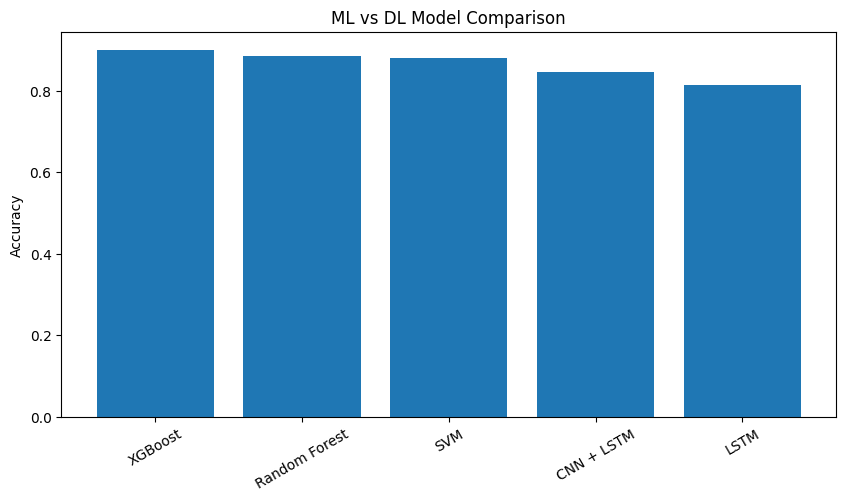

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Import StandardScaler for ML models
from sklearn.preprocessing import StandardScaler

# ====================================
# STORE RESULTS
# ====================================

results = []

# ====================================
# FUNCTION TO SAVE RESULTS
# ====================================

def evaluate_model(model_name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    results.append([
        model_name,
        acc,
        precision,
        recall,
        f1
    ])

# ====================================
# MACHINE LEARNING MODELS
# ====================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

ml_models = {

    "SVM":
        SVC(kernel='rbf'),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric='logloss'
        )
}

print("Training ML Models...\n")

# --- FIX: Prepare scaled 2D data for ML models ---
# Flatten the 3D X_train and X_test to 2D for traditional ML models
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train_2d)
X_test_scaled = scaler_ml.transform(X_test_2d)
# --- END FIX ---

for name, model in ml_models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    evaluate_model(
        name,
        y_test,
        pred
    )

    print(f"{name} completed")

# ====================================
# LSTM MODEL
# ====================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)
import tensorflow as tf # Import tensorflow for clear_session

tf.keras.backend.clear_session() # Clear session before defining new Keras model

print("\nTraining LSTM...\n")

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        128,
        input_shape=(80,200) # FIX: Changed from (40,200) to (80,200) to match current X_train shape
    )
)

lstm_model.add(
    Dropout(0.3)
)

lstm_model.add(
    Dense(
        64,
        activation='relu'
    )
)

lstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train.squeeze(), # FIX: Use .squeeze() to remove the extra dimension for LSTM input
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred_prob = lstm_model.predict(X_test.squeeze()) # FIX: Use .squeeze() for prediction input

pred = (pred_prob > 0.5).astype(int)

evaluate_model(
    "LSTM",
    y_test,
    pred
)

# ====================================
# CNN + LSTM
# ====================================

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D
)

tf.keras.backend.clear_session() # Clear session before defining new Keras model

print("\nTraining CNN+LSTM...\n")

cnn_lstm = Sequential()

cnn_lstm.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(80,200) # FIX: Changed from (40,200) to (80,200) to match current X_train shape
    )
)

cnn_lstm.add(
    MaxPooling1D(pool_size=2)
)

cnn_lstm.add(
    LSTM(128)
)

cnn_lstm.add(
    Dropout(0.3)
)

cnn_lstm.add(
    Dense(
        64,
        activation='relu'
    )
)

cnn_lstm.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

cnn_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_lstm.fit(
    X_train.squeeze(), # FIX: Use .squeeze() to remove the extra dimension for Conv1D+LSTM input
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred_prob = cnn_lstm.predict(X_test.squeeze()) # FIX: Use .squeeze() for prediction input

pred = (pred_prob > 0.5).astype(int)

evaluate_model(
    "CNN + LSTM",
    y_test,
    pred
)

# ====================================
# COMPARISON TABLE
# ====================================

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Comparison\n")
print(comparison_df)

# ====================================
# GRAPH
# ====================================

plt.figure(figsize=(10,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xticks(rotation=30)

plt.ylabel("Accuracy")

plt.title(
    "ML vs DL Model Comparison"
)

plt.show()

In [ ]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(3240, 80, 200, 1)
(2592, 80, 200, 1)
(648, 80, 200, 1)


RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Dropout
)

import tensorflow as tf

tf.keras.backend.clear_session()

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        128,
        input_shape=(80, 200)
    )
)

rnn_model.add(
    Dropout(0.3)
)

rnn_model.add(
    Dense(
        64,
        activation='relu'
    )
)

rnn_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        42,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,433 (197.00 KB)

 Trainable params: 50,433 (197.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_history = rnn_model.fit(
    X_train.squeeze(),
    y_train,
    validation_data=(
        X_test.squeeze(),
        y_test
    ),
    epochs=100,
    batch_size=32
)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7724 - loss: 0.5046 - val_accuracy: 0.8071 - val_loss: 0.4408
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8291 - loss: 0.3949 - val_accuracy: 0.8225 - val_loss: 0.4080
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8654 - loss: 0.3226 - val_accuracy: 0.8256 - val_loss: 0.4035
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8958 - loss: 0.2632 - val_accuracy: 0.8210 - val_loss: 0.4022
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9263 - loss: 0.1959 - val_accuracy: 0.8102 - val_loss: 0.4600
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9479 - loss: 0.1495 - val_accuracy: 0.8040 - val_loss: 0.5167
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9591 - loss: 0.1072 - val_accuracy: 0.8086 - val_loss: 0.5247
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9807 - loss: 0.0658 - val_accuracy: 0

In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test.squeeze(),
    y_test
)

print("RNN Accuracy:", rnn_acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7932 - loss: 1.4581
RNN Accuracy: 0.7932098507881165


improved version

RNN + CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    SimpleRNN,
    Dense,
    Dropout
)

import tensorflow as tf

tf.keras.backend.clear_session()

rnn_cnn = Sequential()

rnn_cnn.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(80,200)
    )
)

rnn_cnn.add(
    MaxPooling1D(pool_size=2)
)

rnn_cnn.add(
    SimpleRNN(128)
)

rnn_cnn.add(
    Dropout(0.3)
)

rnn_cnn.add(
    Dense(
        64,
        activation='relu'
    )
)

rnn_cnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

rnn_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 78, 64)         │        38,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,489 (279.25 KB)

 Trainable params: 71,489 (279.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = rnn_cnn.fit(
    X_train.squeeze(),
    y_train,
    validation_data=(
        X_test.squeeze(),
        y_test
    ),
    epochs=200,
    batch_size=32
)

Epoch 1/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 1.4930e-05 - val_accuracy: 0.8102 - val_loss: 1.6366
Epoch 2/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 1.6538e-05 - val_accuracy: 0.8102 - val_loss: 1.6461
Epoch 3/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 1.8497e-05 - val_accuracy: 0.8086 - val_loss: 1.6607
Epoch 4/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 1.6405e-05 - val_accuracy: 0.8086 - val_loss: 1.6647
Epoch 5/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 1.2718e-05 - val_accuracy: 0.8071 - val_loss: 1.6724
Epoch 6/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 1.1697e-05 - val_accuracy: 0.8071 - val_loss: 1.6818
Epoch 7/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 1.3338e-05 - val_accuracy: 0.8056 - val_loss: 1.6983
Epoch 8/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - los

RNN+LSTM+CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

hybrid_model = Sequential()

# CNN
hybrid_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(40,200)
    )
)

hybrid_model.add(
    MaxPooling1D(pool_size=2)
)

# RNN
hybrid_model.add(
    SimpleRNN(
        64,
        return_sequences=True
    )
)

# LSTM
hybrid_model.add(
    LSTM(128)
)

hybrid_model.add(
    Dropout(0.3)
)

hybrid_model.add(
    Dense(
        64,
        activation='relu'
    )
)

hybrid_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

hybrid_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 38, 64)         │        38,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 19, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,857 (601.00 KB)

 Trainable params: 153,857 (601.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = hybrid_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=30,
    batch_size=32
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.8044 - loss: 0.4454 - val_accuracy: 0.8642 - val_loss: 0.3007
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.8580 - loss: 0.3497 - val_accuracy: 0.8873 - val_loss: 0.2641
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8843 - loss: 0.3039 - val_accuracy: 0.8858 - val_loss: 0.2858
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8904 - loss: 0.2750 - val_accuracy: 0.8827 - val_loss: 0.2740
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8985 - loss: 0.2565 - val_accuracy: 0.8904 - val_loss: 0.2716
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9012 - loss: 0.2318 - val_accuracy: 0.8519 - val_loss: 0.3660
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9120 - loss: 0.2158 - val_accuracy: 0.8596 - val_loss: 0.3256
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9325 - loss: 0.1630 - val_accuracy: 0.8904 - 

In [ ]:
import pandas as pd

results = {

    "SVM": svm_acc,
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc,
    "LSTM": lstm_acc,
    "CNN+LSTM": cnn_lstm_acc,
    "RNN": rnn_acc,
    "RNN+CNN": rnn_cnn_acc,
    "RNN+CNN+LSTM": hybrid_acc
}

df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

# Sort highest to lowest
df = df.sort_values(
    by="Accuracy",
    ascending=False
)

print(df)

NameError: name 'svm_acc' is not defined

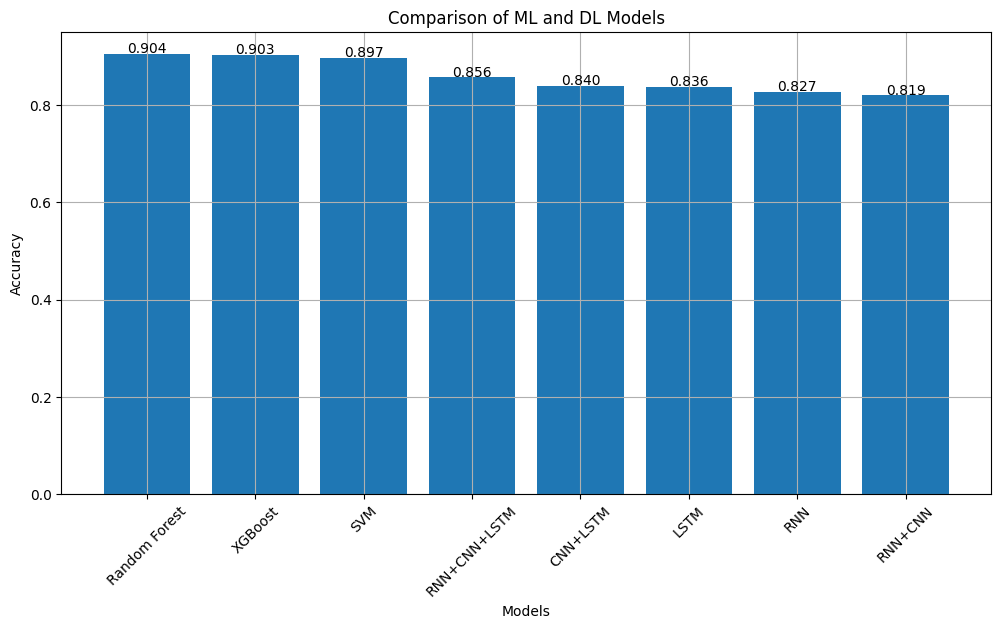

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bars = plt.bar(
    df["Model"],
    df["Accuracy"]
)

# Show value on top of bars
for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.002,
        f"{y:.3f}",
        ha='center'
    )

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title(
    "Comparison of ML and DL Models"
)

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [ ]:
!pip install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 6.6 MB/s eta 0:00:00


In [ ]:
from flaml import AutoML

automl = AutoML()

settings = {
    "time_budget": 300,
    "metric": 'accuracy',
    "task": 'classification'
}

automl.fit(
    X_train=X_train,
    y_train=y_train,
    **settings
)

pred = automl.predict(X_test)

from sklearn.metrics import accuracy_score

print(
    "AutoML Accuracy:",
    accuracy_score(y_test, pred)
)

print(
    automl.model
)

[flaml.automl.logger: 05-19 06:37:28] {2375} INFO - task = classification
[flaml.automl.logger: 05-19 06:37:28] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-19 06:37:28] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-19 06:37:28] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 05-19 06:37:28] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-19 06:37:28] {3046} INFO - Estimated sufficient time budget=1884s. Estimated necessary time budget=46s.
[flaml.automl.logger: 05-19 06:37:28] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.0525e-01,	best estimator lgbm's best error=2.0525e-01
[flaml.automl.logger: 05-19 06:37:28] {2911} INFO - iteration 1, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[flaml.automl.logger: 05-19 06:37:28] {3097} INFO -  at 0.4s,	estimator lgbm's best error=2.0525e-01,	best estimator lgbm's best error=2.0525e-01
[flaml.automl.logger: 05-19 06:37:28] {2911} INFO - iteration 2, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[flaml.automl.logger: 05-19 06:37:28] {3097} INFO -  at 0.6s,	estimator lgbm's best error=1.3311e-01,	best estimator lgbm's best error=1.3311e-01
[flaml.automl.logger: 05-19 06:37:28] {2911} INFO - iteration 3, current learner sgd


...

[flaml.automl.logger: 05-19 06:41:43] {3097} INFO -  at 255.2s,	estimator extra_tree's best error=9.8777e-02,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:41:43] {2911} INFO - iteration 142, current learner sgd
[flaml.automl.logger: 05-19 06:41:43] {3097} INFO -  at 255.3s,	estimator sgd's best error=2.0525e-01,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:41:43] {2911} INFO - iteration 143, current learner extra_tree
[flaml.automl.logger: 05-19 06:41:44] {3097} INFO -  at 255.7s,	estimator extra_tree's best error=9.8777e-02,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:41:44] {2911} INFO - iteration 144, current learner sgd
[flaml.automl.logger: 05-19 06:41:44] {3097} INFO -  at 255.9s,	estimator sgd's best error=2.0525e-01,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:41:44] {2911} INFO - iteration 145, current learner sgd
[flaml.automl.logge

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 05-19 06:41:50] {3097} INFO -  at 262.5s,	estimator lgbm's best error=1.0880e-01,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:41:50] {2911} INFO - iteration 156, current learner extra_tree


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 05-19 06:41:51] {3097} INFO -  at 263.4s,	estimator extra_tree's best error=9.8777e-02,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:41:51] {2911} INFO - iteration 157, current learner catboost
[flaml.automl.logger: 05-19 06:42:27] {3097} INFO -  at 299.4s,	estimator catboost's best error=1.0302e-01,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:42:27] {2911} INFO - iteration 158, current learner sgd
[flaml.automl.logger: 05-19 06:42:28] {3097} INFO -  at 299.7s,	estimator sgd's best error=2.0525e-01,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:42:28] {2911} INFO - iteration 159, current learner sgd
[flaml.automl.logger: 05-19 06:42:28] {3097} INFO -  at 299.8s,	estimator sgd's best error=2.0525e-01,	best estimator extra_tree's best error=9.8777e-02
[flaml.automl.logger: 05-19 06:42:28] {2911} INFO - iteration 160, current learner sgd
[flaml.automl.logger: 0

improved version


In [ ]:
import os
import librosa
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dense,
    Dropout,
    Flatten,
    Bidirectional,
    LSTM,
    Reshape
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("Libraries Loaded")

Libraries Loaded


In [ ]:
folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

base_path = "/content/physionet/physionet.0.0"

In [ ]:
def add_noise(signal):

    noise = np.random.randn(len(signal))

    augmented = signal + 0.005 * noise

    return augmented


def time_stretch(signal):

    return librosa.effects.time_stretch(
        signal,
        rate=1.1
    )


def pitch_shift(signal, sr):

    return librosa.effects.pitch_shift(
        signal,
        sr=sr,
        n_steps=2
    )

In [ ]:
MAX_LEN = 200

def extract_features(signal, sr):

    # DWT Denoising
    coeffs = pywt.wavedec(
        signal,
        'db4',
        level=4
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            0.04,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        'db4'
    )

    # Normalize
    denoised = denoised / np.max(
        np.abs(denoised)
    )

    # Trim silence
    denoised, _ = librosa.effects.trim(
        denoised,
        top_db=20
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=denoised,
        sr=sr,
        n_mfcc=40
    )

    # Delta
    delta = librosa.feature.delta(
        mfcc
    )

    # Delta2
    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=denoised,
        sr=sr,
        n_mels=40
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # Combine all features
    features = np.vstack([
        mfcc,
        delta,
        delta2,
        mel_db
    ])

    # Padding
    if features.shape[1] < MAX_LEN:

        pad_width = (
            MAX_LEN -
            features.shape[1]
        )

        features = np.pad(
            features,
            pad_width=((0,0),
                        (0,pad_width)),
            mode='constant'
        )

    else:

        features = features[:, :MAX_LEN]

    return features

In [ ]:
import os
import librosa
import pywt
import numpy as np
import pandas as pd

# -----------------------
# Dataset folders
# -----------------------

folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

base_path = "/content/physionet/physionet.0.0"

# -----------------------
# Storage
# -----------------------

X = []
y = []

MAX_LEN = 100

# -----------------------
# Feature Extraction
# -----------------------

def extract_features(signal, sr):

    # DWT Denoising
    coeffs = pywt.wavedec(
        signal,
        'db4',
        level=4
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            value=0.04,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        'db4'
    )

    # Normalize audio
    denoised = denoised / (
        np.max(np.abs(denoised)) + 1e-8
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=denoised,
        sr=sr,
        n_mfcc=40
    )

    # Fix short file issue
    if mfcc.shape[1] < 9:

        mfcc = np.pad(
            mfcc,
            ((0,0), (0, 9-mfcc.shape[1])),
            mode='constant'
        )

    # Delta
    delta = librosa.feature.delta(
        mfcc
    )

    # Combine Features
    features = np.vstack([
        mfcc,
        delta
    ])

    # Padding
    if features.shape[1] < MAX_LEN:

        pad_width = (
            MAX_LEN -
            features.shape[1]
        )

        features = np.pad(
            features,
            ((0,0), (0,pad_width)),
            mode='constant'
        )

    else:

        features = features[
            :, :MAX_LEN
        ]

    return features


# -----------------------
# Load Dataset
# -----------------------

for folder in folders:

    folder_path = os.path.join(
        base_path,
        folder
    )

    label_file = os.path.join(
        folder_path,
        "REFERENCE.csv"
    )

    labels = pd.read_csv(
        label_file,
        header=None
    )

    labels.columns = [
        'file',
        'label'
    ]

    labels['label'] = labels[
        'label'
    ].map({
        -1:0,
         1:1
    })

    print(
        "Processing:",
        folder
    )

    for _, row in labels.iterrows():

        file_name = row['file']
        label = row['label']

        wav_path = os.path.join(
            folder_path,
            file_name + ".wav"
        )

        try:

            signal, sr = librosa.load(
                wav_path,
                sr=2000
            )

            feature = extract_features(
                signal,
                sr
            )

            X.append(feature)
            y.append(label)

        except Exception as e:

            print(
                "Skipped:",
                wav_path
            )

            print(e)

# Convert
X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

print(X.shape)
print(y.shape)
print(np.bincount(y))

Processing: training-a
Processing: training-b
Processing: training-c
Processing: training-d
Processing: training-e
Processing: training-f
(3240, 80, 100)
(3240,)
[2575  665]


In [ ]:
from sklearn.model_selection import train_test_split

# Normalize
X = (
    X - np.mean(X)
) / np.std(X)

# Add channel
X = np.expand_dims(
    X,
    axis=-1
)

print(X.shape)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3240, 80, 100, 1)
(2592, 80, 100, 1)
(648, 80, 100, 1)


In [ ]:
from sklearn.utils.class_weight import (
    compute_class_weight
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(0.629126213592233), 1: np.float64(2.43609022556391)}


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Reshape,
    Bidirectional,
    LSTM,
    Dense
)

from tensorflow.keras.optimizers import Adam

input_layer = Input(
    shape=(80, 100, 1)
)

# CNN Block 1
x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_layer)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.3)(x)

# CNN Block 2
x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.3)(x)

# Reshape for BiLSTM
x = Reshape(
    (20, 1600)
)(x)

# BiLSTM
x = Bidirectional(
    LSTM(
        128,
        return_sequences=False
    )
)(x)

x = Dropout(0.4)(x)

# Dense
x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

# Output
output = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 80, 100, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 80, 100, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 80, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 100, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 40, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 20, 1600)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │     1,770,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,852,385 (7.07 MB)

 Trainable params: 1,852,193 (7.07 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.5576 - loss: 0.7128 - val_accuracy: 0.3160 - val_loss: 0.7039 - learning_rate: 1.0000e-04
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5876 - loss: 0.6748 - val_accuracy: 0.5145 - val_loss: 0.6875 - learning_rate: 1.0000e-04
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5519 - loss: 0.6721 - val_accuracy: 0.7669 - val_loss: 0.6012 - learning_rate: 1.0000e-04
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6372 - loss: 0.6294 - val_accuracy: 0.7746 - val_loss: 0.4905 - learning_rate: 1.0000e-04
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7028 - loss: 0.5674 - val_accuracy: 0.7630 - val_loss: 0.4785 - learning_rate: 1.0000e-04
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7226 - loss: 0.5364 - val_accuracy: 0.7052 - val_loss: 0.4629 - learning_rate: 1.0000e-04
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - ac

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    round(test_acc * 100, 2),
    "%"
)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8503 - loss: 0.3075
Test Accuracy: 85.03 %


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Prediction
y_pred_prob = model.predict(
    X_test
)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       515
           1       0.61      0.74      0.67       133

    accuracy                           0.85       648
   macro avg       0.77      0.81      0.79       648
weighted avg       0.86      0.85      0.86       648



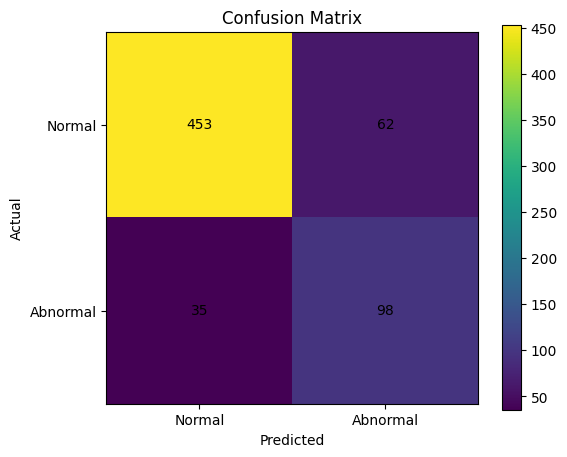

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1],
           ['Normal','Abnormal'])

plt.yticks([0,1],
           ['Normal','Abnormal'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [ ]:
def extract_features(signal, sr):

    # DWT Denoising
    coeffs = pywt.wavedec(
        signal,
        'db4',
        level=4
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            value=0.04,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        'db4'
    )

    # Normalize audio
    denoised = denoised / (
        np.max(np.abs(denoised)) + 1e-8
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=denoised,
        sr=sr,
        n_mfcc=30
    )

    # Fix short audio
    if mfcc.shape[1] < 9:

        mfcc = np.pad(
            mfcc,
            ((0,0), (0,9-mfcc.shape[1])),
            mode='constant'
        )

    # Delta
    delta = librosa.feature.delta(
        mfcc
    )

    # Delta²
    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Combine
    features = np.vstack([
        mfcc,
        delta,
        delta2
    ])

    MAX_LEN = 100

    # Padding
    if features.shape[1] < MAX_LEN:

        pad_width = (
            MAX_LEN -
            features.shape[1]
        )

        features = np.pad(
            features,
            ((0,0),
             (0,pad_width)),
            mode='constant'
        )

    else:

        features = features[
            :, :MAX_LEN
        ]

    return features

In [ ]:
import os
import librosa
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    Bidirectional,
    LSTM,
    Reshape
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

In [ ]:
folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

base_path = "/content/physionet/physionet.0.0"

In [ ]:
MAX_LEN = 100

def extract_features(signal, sr):

    # -----------------------
    # Normalize
    # -----------------------

    signal = signal / (
        np.max(np.abs(signal))
        + 1e-8
    )

    # -----------------------
    # DWT Denoise
    # -----------------------

    coeffs = pywt.wavedec(
        signal,
        'db4',
        level=4
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            0.04,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        'db4'
    )

    # -----------------------
    # MFCC
    # -----------------------

    mfcc = librosa.feature.mfcc(
        y=denoised,
        sr=sr,
        n_mfcc=30
    )

    # -----------------------
    # Delta
    # -----------------------

    delta = librosa.feature.delta(
        mfcc
    )

    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    # 30 + 30 + 30 = 90

    features = np.vstack([
        mfcc,
        delta,
        delta2
    ])

    # -----------------------
    # Padding
    # -----------------------

    if features.shape[1] < MAX_LEN:

        pad = (
            MAX_LEN
            -
            features.shape[1]
        )

        features = np.pad(
            features,
            (
                (0,0),
                (0,pad)
            ),
            mode='constant'
        )

    else:

        features = features[
            :,
            :MAX_LEN
        ]

    return features

In [ ]:
X = []
y = []

for folder in folders:

    folder_path = os.path.join(
        base_path,
        folder
    )

    label_file = os.path.join(
        folder_path,
        "REFERENCE.csv"
    )

    labels = pd.read_csv(
        label_file,
        header=None
    )

    labels.columns = [
        'file',
        'label'
    ]

    labels['label'] = labels[
        'label'
    ].map({
        -1:0,
         1:1
    })

    print(
        "Processing:",
        folder
    )

    for _, row in labels.iterrows():

        file_name = row['file']
        label = row['label']

        wav_path = os.path.join(
            folder_path,
            file_name + ".wav"
        )

        try:

            signal, sr = librosa.load(
                wav_path,
                sr=2000
            )

            # Original
            feature = extract_features(
                signal,
                sr
            )

            X.append(feature)
            y.append(label)

            # Noise augmentation
            noise = np.random.normal(
                0,
                0.002,
                len(signal)
            )

            aug_signal = (
                signal + noise
            )

            aug_feature = (
                extract_features(
                    aug_signal,
                    sr
                )
            )

            X.append(
                aug_feature
            )

            y.append(label)

        except Exception as e:

            print(
                "Skipped:",
                wav_path
            )

            print(e)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

print(X.shape)
print(y.shape)
print(np.bincount(y))

Processing: training-a
Processing: training-b
Processing: training-c
Processing: training-d
Processing: training-e
Processing: training-f
(6480, 90, 100)
(6480,)
[5150 1330]


In [ ]:
# Normalize
X = (
    X - np.mean(X)
) / np.std(X)

# CNN channel
X = np.expand_dims(
    X,
    axis=-1
)

print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6480, 90, 100, 1)
(5184, 90, 100, 1)
(1296, 90, 100, 1)


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(0.629126213592233), 1: np.float64(2.43609022556391)}


In [ ]:
# Normalize
X = (
    X - np.mean(X)
) / np.std(X)

# CNN channel
X = np.expand_dims(
    X,
    axis=-1
)

print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6480, 90, 100, 1)
(5184, 90, 100, 1)
(1296, 90, 100, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    Bidirectional,
    LSTM,
    Reshape
)

from tensorflow.keras.optimizers import Adam

# -------------------
# Input
# -------------------

input_layer = Input(
    shape=(90, 100, 1)
)

# -------------------
# CNN Block 1
# -------------------

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_layer)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.3)(x)

# -------------------
# CNN Block 2
# -------------------

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.3)(x)

# -------------------
# CNN Block 3
# -------------------

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.3)(x)

# -------------------
# Reshape for LSTM
# -------------------

x = Reshape(
    (11, 1536)
)(x)

# -------------------
# BiLSTM
# -------------------

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(x)

x = Dropout(0.4)(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=False
    )
)(x)

x = Dropout(0.4)(x)

# -------------------
# Dense Layers
# -------------------

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

# -------------------
# Output
# -------------------

output = Dense(
    1,
    activation='sigmoid'
)(x)

# -------------------
# Model
# -------------------

model = Model(
    inputs=input_layer,
    outputs=output
)

model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 90, 100, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 90, 100, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 90, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 90, 100, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 45, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 45, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 45, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 45, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 22, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 22, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 22, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 11, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 11, 1536)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 11, 256)        │     1,704,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 11, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,033,889 (7.76 MB)

 Trainable params: 2,033,441 (7.76 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=70,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.5614 - loss: 0.6884 - val_accuracy: 0.7936 - val_loss: 0.5828 - learning_rate: 1.0000e-04
Epoch 2/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7007 - loss: 0.6124 - val_accuracy: 0.7936 - val_loss: 0.4796 - learning_rate: 1.0000e-04
Epoch 3/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7343 - loss: 0.5028 - val_accuracy: 0.8322 - val_loss: 0.3950 - learning_rate: 1.0000e-04
Epoch 4/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7468 - loss: 0.4616 - val_accuracy: 0.8486 - val_loss: 0.3755 - learning_rate: 1.0000e-04
Epoch 5/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7499 - loss: 0.4403 - val_accuracy: 0.8467 - val_loss: 0.3690 - learning_rate: 1.0000e-04
Epoch 6/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7654 - loss: 0.4178 - val_accuracy: 0.8640 - val_loss: 0.3423 - learning_rate: 1.0000e-04
Epoch 7/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step 

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    round(test_acc * 100, 2),
    "%"
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8727 - loss: 0.2774
Test Accuracy: 87.27 %


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Prediction
y_pred_prob = model.predict(
    X_test
)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1030
           1       0.70      0.67      0.68       266

    accuracy                           0.87      1296
   macro avg       0.81      0.80      0.80      1296
weighted avg       0.87      0.87      0.87      1296



In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    Bidirectional,
    LSTM,
    Reshape,
    Attention,
    GlobalAveragePooling1D
)

from tensorflow.keras.optimizers import Adam


# -----------------------
# Focal Loss
# -----------------------

def focal_loss(gamma=2., alpha=0.25):

    def loss(y_true, y_pred):

        y_true = tf.cast(
            y_true,
            tf.float32
        )

        bce = tf.keras.backend.binary_crossentropy(
            y_true,
            y_pred
        )

        p_t = (
            y_true * y_pred
            +
            (1 - y_true)
            *
            (1 - y_pred)
        )

        focal = (
            alpha
            *
            tf.pow(
                (1 - p_t),
                gamma
            )
            *
            bce
        )

        return tf.reduce_mean(
            focal
        )

    return loss


# -----------------------
# Input
# -----------------------

input_layer = Input(
    shape=(90,100,1)
)

# -----------------------
# CNN BLOCK 1
# -----------------------

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_layer)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.25)(x)

# -----------------------
# CNN BLOCK 2
# -----------------------

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.30)(x)

# -----------------------
# CNN BLOCK 3
# -----------------------

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2)
)(x)

x = Dropout(0.30)(x)

# -----------------------
# Reshape for BiLSTM
# -----------------------

x = Reshape(
    (11,1536)
)(x)

# -----------------------
# BiLSTM
# -----------------------

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(x)

x = Dropout(0.4)(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    )
)(x)

# -----------------------
# Attention Layer
# -----------------------

attention = Attention()(
    [x, x]
)

x = GlobalAveragePooling1D()(
    attention
)

x = Dropout(0.4)(x)

# -----------------------
# Dense
# -----------------------

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

# -----------------------
# Output
# -----------------------

output = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss=focal_loss(),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 90, 100,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 90, 100,   │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 100,   │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 90, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 45, 50,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 45, 50,    │          0 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 45, 50,    │     18,496 │ dropout_3[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 50,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 45, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 22, 25,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 22, 25,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 22, 25,    │     73,856 │ dropout_4[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 25,    │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 11, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 11, 12,    │          0 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 11, 1536)  │          0 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 11, 256)   │  1,704,960 │ reshape_1[0][0]   │
│ (Bidirectional)     │                   │            │                 

 Total params: 2,033,889 (7.76 MB)

 Trainable params: 2,033,441 (7.76 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/100
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9326 - loss: 0.0118
Epoch 1: val_accuracy did not improve from 0.89200
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9301 - loss: 0.0119 - val_accuracy: 0.8910 - val_loss: 0.0144 - learning_rate: 2.5000e-05
Epoch 2/100
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9357 - loss: 0.0108
Epoch 2: val_accuracy did not improve from 0.89200
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.9306 - loss: 0.0112 - val_accuracy: 0.8872 - val_loss: 0.0149 - learning_rate: 2.5000e-05
Epoch 3/100
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9344 - loss: 0.0107
Epoch 3: val_accuracy did not improve from 0.89200
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9325 - loss: 0.0113 - val_accuracy: 0.8843 - val_loss: 0.0154 - learning_rate: 2.5000e-05
Epoch 4/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9295 - loss: 0.0118
Epoch 4: val_accuracy did not improve from 0.89200
260

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    round(test_acc * 100, 2),
    "%"
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8989 - loss: 0.0134
Test Accuracy: 89.89 %


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Prediction
y_pred_prob = model.predict(
    X_test
)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1030
           1       0.89      0.58      0.70       266

    accuracy                           0.90      1296
   macro avg       0.89      0.78      0.82      1296
weighted avg       0.90      0.90      0.89      1296



In [ ]:
MAX_LEN = 120

def extract_features(signal, sr):

    # -------------------
    # Normalize
    # -------------------

    signal = signal / (
        np.max(np.abs(signal)) + 1e-8
    )

    # -------------------
    # DWT Denoise
    # -------------------

    coeffs = pywt.wavedec(
        signal,
        'db6',
        level=5
    )

    sigma = np.median(
        np.abs(coeffs[-1])
    ) / 0.6745

    threshold = sigma * np.sqrt(
        2 * np.log(len(signal))
    )

    coeffs[1:] = [
        pywt.threshold(
            c,
            threshold,
            mode='soft'
        )
        for c in coeffs[1:]
    ]

    denoised = pywt.waverec(
        coeffs,
        'db6'
    )

    # -------------------
    # MFCC
    # -------------------

    mfcc = librosa.feature.mfcc(
        y=denoised,
        sr=sr,
        n_mfcc=40,
        n_fft=1024,
        hop_length=256
    )

    # Delta
    delta = librosa.feature.delta(
        mfcc
    )

    # Delta²
    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    features = np.vstack([
        mfcc,
        delta,
        delta2
    ])

    # -------------------
    # Padding
    # -------------------

    if features.shape[1] < MAX_LEN:

        pad = (
            MAX_LEN -
            features.shape[1]
        )

        features = np.pad(
            features,
            ((0,0),(0,pad)),
            mode='constant'
        )

    else:

        features = features[
            :, :MAX_LEN
        ]

    return features

In [ ]:
print(X.shape)

(6480, 90, 100, 1)


In [ ]:
X = (
    X - np.mean(X)
) / np.std(X)

X = np.expand_dims(
    X,
    axis=-1
)

print(X.shape)

(6480, 120, 120, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import AdamW

input_layer = Input(shape=(90,100,1))

# -------------------------
# CNN BLOCK 1
# -------------------------

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_layer)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.25)(x)

# -------------------------
# CNN BLOCK 2
# -------------------------

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.30)(x)

# -------------------------
# CNN BLOCK 3
# -------------------------

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.30)(x)

print(x.shape)

# Shape:
# (None, 11, 12, 128)

# -------------------------
# Reshape
# -------------------------

x = Reshape(
    (11,1536)
)(x)

# -------------------------
# BiLSTM
# -------------------------

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(x)

x = Dropout(0.4)(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    )
)(x)

# -------------------------
# Attention
# -------------------------

attention = Attention()(
    [x, x]
)

x = GlobalAveragePooling1D()(
    attention
)

# -------------------------
# Dense
# -------------------------

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.4)(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    input_layer,
    output
)

model.compile(
    optimizer=AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

(None, 11, 12, 128)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 90, 100,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 90, 100,   │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 100,   │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 90, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 45, 50,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 45, 50,    │          0 │ max_pooling2d_9[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 45, 50,    │     18,496 │ dropout_17[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 50,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 45, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 22, 25,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 22, 25,    │          0 │ max_pooling2d_10… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 22, 25,    │     73,856 │ dropout_18[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 25,    │        512 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 11, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 11, 12,    │          0 │ max_pooling2d_11… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 11, 1536)  │          0 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 11, 256)   │  1,704,960 │ reshape_3[0][0]   │
│ (Bidirectional)     │                   │            │                 

 Total params: 2,033,889 (7.76 MB)

 Trainable params: 2,033,441 (7.76 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5184, 90, 100, 1)
(1296, 90, 100, 1)


In [ ]:
history = model.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=120,

    batch_size=16,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/120
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7911 - loss: 0.5287
Epoch 1: val_accuracy improved from None to 0.79364, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7919 - loss: 0.5070 - val_accuracy: 0.7936 - val_loss: 0.5530 - learning_rate: 1.0000e-04
Epoch 2/120
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8049 - loss: 0.4358
Epoch 2: val_accuracy improved from 0.79364 to 0.82353, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8237 - loss: 0.3952 - val_accuracy: 0.8235 - val_loss: 0.3842 - learning_rate: 1.0000e-04
Epoch 3/120
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8553 - loss: 0.3401
Epoch 3: val_accuracy improved from 0.82353 to 0.85632, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
260/260 ━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    round(test_acc * 100, 2),
    "%"
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9066 - loss: 0.2279
Test Accuracy: 90.66 %


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Prediction
y_pred_prob = model.predict(
    X_test
)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1030
           1       0.85      0.66      0.74       266

    accuracy                           0.91      1296
   macro avg       0.88      0.82      0.84      1296
weighted avg       0.90      0.91      0.90      1296



cnn+bilstm

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.629126213592233), 1: np.float64(2.43609022556391)}


In [ ]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(90,100,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.2),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.3),

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.3),

    # Reshape for BiLSTM
    Reshape((12, 1408)),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    Dropout(0.4),

    Bidirectional(
        LSTM(64)
    ),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 90, 100, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 90, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 45, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 45, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 45, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 45, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 22, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 22, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 22, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 22, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 11, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 11, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 12, 1408)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 12, 256)        │     1,573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,856,641 (7.08 MB)

 Trainable params: 1,856,193 (7.08 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=100,

    batch_size=16,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/100
323/324 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5384 - loss: 0.7887
Epoch 1: val_accuracy improved from None to 0.79475, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.6167 - loss: 0.7579 - val_accuracy: 0.7948 - val_loss: 0.6810 - learning_rate: 1.0000e-04
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7566 - loss: 0.6039
Epoch 2: val_accuracy improved from 0.79475 to 0.86651, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
324/324 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7701 - loss: 0.5816 - val_accuracy: 0.8665 - val_loss: 0.4281 - learning_rate: 1.0000e-04
Epoch 3/100
323/324 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7583 - loss: 0.5574
Epoch 3: val_accuracy improved from 0.86651 to 0.86960, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
324/324 ━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    round(test_acc * 100, 2),
    "%"
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8935 - loss: 0.1902
Test Accuracy: 89.35 %


In [ ]:
from sklearn.metrics import classification_report
import tensorflow as tf

# Assuming focal_loss was defined previously in the notebook
# If not, you need to include its definition here or in an earlier cell
def focal_loss(gamma=2., alpha=0.25):

    def loss(y_true, y_pred):

        y_true = tf.cast(
            y_true,
            tf.float32
        )

        bce = tf.keras.backend.binary_crossentropy(
            y_true,
            y_pred
        )

        p_t = (
            y_true * y_pred
            +
            (1 - y_true)
            *
            (1 - y_pred)
        )

        focal = (
            alpha
            *
            tf.pow(
                (1 - p_t),
                gamma
            )
            *
            bce
        )

        return tf.reduce_mean(
            focal
        )

    return loss

# Load the best model
loaded_model = tf.keras.models.load_model(
    'best_model.keras',
    custom_objects={'loss': focal_loss()}
)

y_pred_prob = loaded_model.predict(X_test)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred
    )
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1030
           1       0.72      0.94      0.81       266

    accuracy                           0.91      1296
   macro avg       0.85      0.92      0.88      1296
weighted avg       0.93      0.91      0.92      1296

